# Demo

> Xingyu Long, Jozsef Arato, Sophia Kury, Anna Miscena, and Raphael Rosenberg. 2026.  
> **HeatMatch: Orientation-Aware Visualization and Comparison of Very Dense Saccade Patterns.**  
> *Proceedings of the ACM on Computer Graphics and Interactive Techniques* (PACMCGIT), 9(2), Article 18.  
> https://doi.org/10.1145/3803539

This notebook demonstrates the two main contributions of HeatMatch:
1. **OOI-coded heatmaps**
2. **HeatMatch similarity**

---

**Before running**, place the following file at the repo root:

- `tests/data_anonymized.csv` — preprocessed saccade dataset, download from [osf.io/f2xhj](https://osf.io/f2xhj/)

## Parameters

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from tqdm.notebook import tqdm

from heatmatch import make_reference_grid, make_orientation_field, Heatmap, compute_similarity

%matplotlib inline

CSV_PATH                     = os.path.join('tests', 'data_anonymized.csv')
W, H                         = 2880, 2160   # stimulus size in pixels
GRID_RESOLUTION              = 200          # reference grid resolution (int → square, or (ny, nx) tuple)
SIGMA                        = 50.0         # Gaussian bandwidth σ (pixels)
OOI                          = 0.0          # Orientation of Interest in degrees: 0=east, 90=north, 180=west, 270=south
OPACITY_DENSITY_WEIGHT       = 1.0          # opacity blend: 1 → density only, 0 → coherence only (recommended 0.5–1.0)
DENSITY_COHERENCE_TRADEOFF   = 0.5          # S_dir weight tradeoff: 1 → density only, 0 → coherence only (recommended ~0.5)

STIMULI     = ['Bettera', 'Craen', 'Heda', 'Munari']
N_SUBJECTS  = 5
RANDOM_SEED = 42

## Compute Orientation Fields

Randomly sample 5 subjects, then compute one orientation field per (stimulus, subject) pair
and one aggregate field per stimulus (all subjects pooled).
Both are reused for heatmap rendering and similarity scoring.

In [2]:
df = pd.read_csv(CSV_PATH)
pts, xx, yy = make_reference_grid(W, H, GRID_RESOLUTION)

rng = np.random.default_rng(RANDOM_SEED)
all_subjects = sorted(df['SUBJECT_ALIAS'].unique())
subjects = sorted(rng.choice(all_subjects, size=N_SUBJECTS, replace=False).tolist())
print(f'Sampled subjects: {subjects}')

# fields[stim][subj]  — individual fields
# agg_fields[stim]    — aggregate over the sampled subjects only
fields     = {stim: {} for stim in STIMULI}
agg_fields = {}

for stim in tqdm(STIMULI, desc='Computing fields'):
    df_stim = df[(df['STIMULUS'] == stim) & (df['SUBJECT_ALIAS'].isin(subjects))]
    for subj in subjects:
        dfg    = df_stim[df_stim['SUBJECT_ALIAS'] == subj]
        onset  = dfg[['SAC_ONSET_X', 'SAC_ONSET_Y']].to_numpy(np.float64)
        offset = dfg[['SAC_OFFSET_X', 'SAC_OFFSET_Y']].to_numpy(np.float64)
        fields[stim][subj] = make_orientation_field(pts, onset, offset, sigma=SIGMA, grid_shape=yy.shape)
    onset  = df_stim[['SAC_ONSET_X', 'SAC_ONSET_Y']].to_numpy(np.float64)
    offset = df_stim[['SAC_OFFSET_X', 'SAC_OFFSET_Y']].to_numpy(np.float64)
    agg_fields[stim] = make_orientation_field(pts, onset, offset, sigma=SIGMA, grid_shape=yy.shape)

Sampled subjects: ['64DJ6X', 'KPE4WF', 'RML5AE', 'T7MRIJ', 'ZXNKBQ']


Computing fields:   0%|          | 0/4 [00:00<?, ?it/s]

## OOI-Coded Heatmaps

4 rows × 6 columns: each row is a stimulus, the first 5 columns are individual subjects,
and the last column is the all-subject aggregate.
Hue encodes mean orientation relative to the OOI; opacity encodes local confidence.

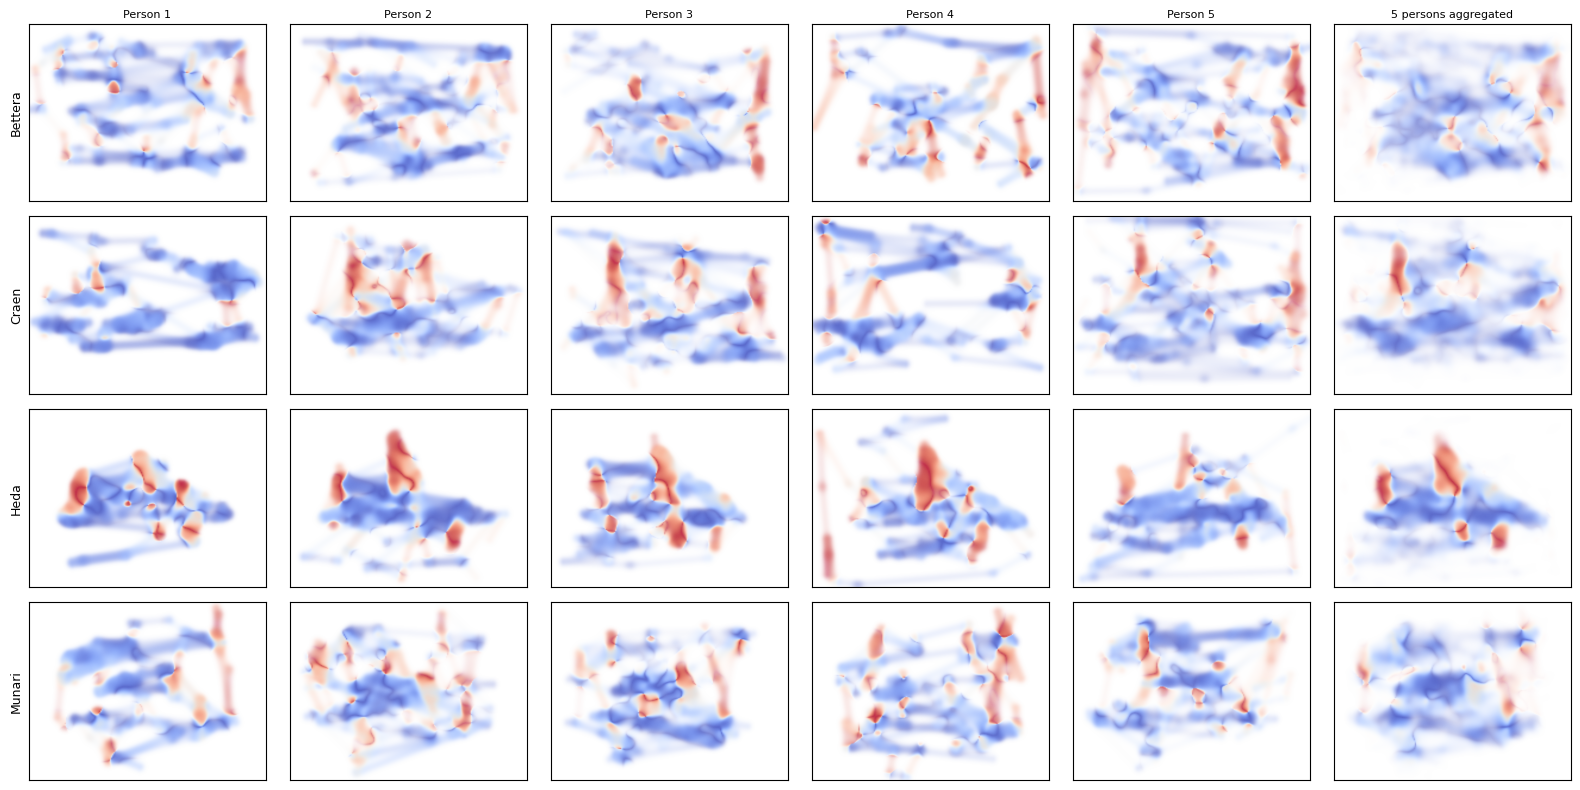

In [3]:
N_COLS = N_SUBJECTS + 1

fig, axes = plt.subplots(len(STIMULI), N_COLS, figsize=(2.0 * N_COLS * W / H, 2.0 * len(STIMULI)))
fig.subplots_adjust(hspace=0.04, wspace=0.04)

for row, stim in enumerate(STIMULI):
    for col, subj in enumerate(subjects):
        ax = axes[row, col]
        Heatmap(fields[stim][subj], W, H).draw(
            ax, ooi=OOI, opacity_density_weight=OPACITY_DENSITY_WEIGHT)
        if row == 0:
            ax.set_title(f'Person {col + 1}', fontsize=8, pad=4)
        if col == 0:
            ax.set_ylabel(stim, fontsize=9, labelpad=4)
    ax = axes[row, N_SUBJECTS]
    Heatmap(agg_fields[stim], W, H).draw(
        ax, ooi=OOI, opacity_density_weight=OPACITY_DENSITY_WEIGHT)
    if row == 0:
        ax.set_title(f'{N_SUBJECTS} persons aggregated', fontsize=8, pad=4)

fig.tight_layout()
plt.show()

## Pairwise Similarity Matrix

For each stimulus pair (including same-stimulus on the diagonal), similarity is computed
for all C(5,2) = 10 subject pairs and averaged. Off-diagonal cells reflect cross-stimulus
similarity; diagonal cells reflect within-stimulus cross-subject consistency — how similarly
different participants explored the same painting.

Stimulus pairs:   0%|          | 0/4 [00:00<?, ?it/s]

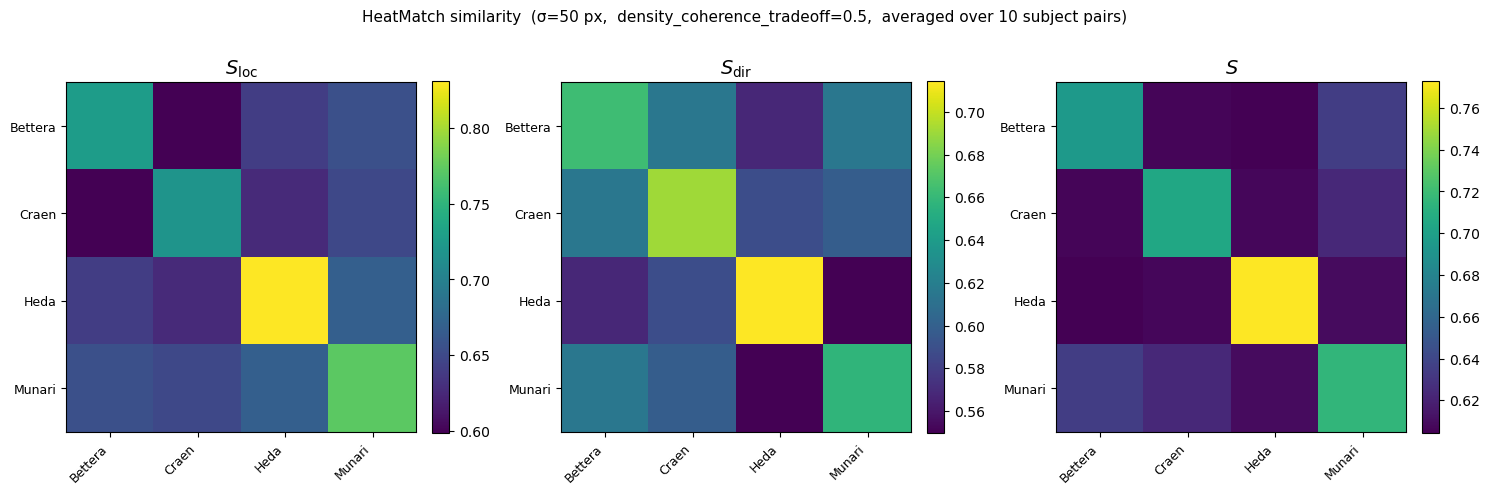

In [4]:
n = len(STIMULI)
s_loc_mat = np.zeros((n, n))
s_dir_mat = np.zeros((n, n))

subj_pairs = list(combinations(subjects, 2))  # C(5,2) = 10 pairs

# All (i, j) with i <= j — diagonal = within-stimulus, off-diagonal = cross-stimulus
for i in tqdm(range(n), desc='Stimulus pairs'):
    for j in range(i, n):
        loc_scores, dir_scores = [], []
        for subj_a, subj_b in subj_pairs:
            result = compute_similarity(fields[STIMULI[i]][subj_a], fields[STIMULI[j]][subj_b],
                                        density_coherence_tradeoff=DENSITY_COHERENCE_TRADEOFF)
            loc_scores.append(result.s_loc)
            dir_scores.append(result.s_dir)
        s_loc_mat[i, j] = s_loc_mat[j, i] = np.mean(loc_scores)
        s_dir_mat[i, j] = s_dir_mat[j, i] = np.mean(dir_scores)

s_avg_mat = (s_loc_mat + s_dir_mat) / 2.0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, mat, title in zip(axes, [s_loc_mat, s_dir_mat, s_avg_mat],
                                 [r'$S_\mathrm{loc}$', r'$S_\mathrm{dir}$', r'$S$']):
    im = ax.imshow(mat, cmap='viridis')
    ax.set_xticks(range(n)); ax.set_xticklabels(STIMULI, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n)); ax.set_yticklabels(STIMULI, fontsize=9)
    ax.set_title(title, fontsize=14)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'HeatMatch similarity  (σ={SIGMA:.0f} px,  density_coherence_tradeoff={DENSITY_COHERENCE_TRADEOFF},  '
             f'averaged over {len(subj_pairs)} subject pairs)', fontsize=11)
fig.tight_layout()
plt.show()